<a href="https://colab.research.google.com/github/gevorgalaverdyan/Multimodal-Bird-Species-Classification/blob/master/Multimodal_Bird_Species_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.models as models

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
import kagglehub

# Download latest version
bird_images_path = kagglehub.dataset_download("wenewone/cub2002011")

bird_spectrograms_path = kagglehub.dataset_download("gevorgalaverdyan/bird-species-audio-spectrograms-cub-200-aligned")

print("Path to IMAGES dataset files:", bird_images_path)
print("Path to Sdataset files:", bird_spectrograms_path)

Using Colab cache for faster access to the 'cub2002011' dataset.


100%|██████████| 828M/828M [00:09<00:00, 88.9MB/s]

Extracting files...


Path to IMAGES dataset files: /kaggle/input/cub2002011
Path to Sdataset files: /root/.cache/kagglehub/datasets/gevorgalaverdyan/bird-species-audio-spectrograms-cub-200-aligned/versions/2


In [ ]:
def show_tree(root, max_depth=2, max_items=10):
    for dirpath, dirnames, filenames in os.walk(root):
        depth = dirpath.replace(root, "").count(os.sep)
        if depth >= max_depth:
            dirnames.clear()   # don't go deeper
            continue
        indent = "  " * depth
        print(f"{indent}{os.path.basename(dirpath)}/")
        # Show a few files at this level
        for f in filenames[:max_items]:
            print(f"{indent}  {f}")
        if len(filenames) > max_items:
            print(f"{indent}  ... ({len(filenames) - max_items} more files)")

print("=== CUB IMAGE DATASET ===")
show_tree(bird_images_path)

print("\n=== SPECTROGRAM DATASET ===")
show_tree(bird_spectrograms_path)

=== CUB IMAGE DATASET ===
cub2002011/
  cvpr2016_cub/
    vocab_c10.t7
    trainclasses.txt
    manifest.txt
    valids.txt
    allclasses.txt
    testclasses.txt
    trainvalclasses.txt
    trainvalids.txt
    valclasses.txt
    trainids.txt
  CUB_200_2011/
    images.txt
    train_test_split.txt
    image_class_labels.txt
    README
    classes.txt
    bounding_boxes.txt
  segmentations/

=== SPECTROGRAM DATASET ===
2/
  README.md
  metadata.csv
  spectrograms/


Parsing the CUB-200 images

In [ ]:
CUB_ROOT  = Path(f"{bird_images_path}/CUB_200_2011")
SPEC_ROOT = Path(bird_spectrograms_path)


# Each file is space-separated with no header
df_images = pd.read_csv(CUB_ROOT / "images.txt",
                        sep=" ", header=None, names=["image_id", "file_path"])

df_labels = pd.read_csv(CUB_ROOT / "image_class_labels.txt",
                        sep=" ", header=None, names=["image_id", "class_id"])

df_split  = pd.read_csv(CUB_ROOT / "train_test_split.txt",
                        sep=" ", header=None, names=["image_id", "is_train"])

df_classes = pd.read_csv(CUB_ROOT / "classes.txt",
                         sep=" ", header=None, names=["class_id", "class_name"])

# Merge everything into one big table
cub_df = (df_images
          .merge(df_labels,  on="image_id")
          .merge(df_split,   on="image_id")
          .merge(df_classes, on="class_id"))

print("CUB dataframe shape:", cub_df.shape)
print(f"Total classes : {cub_df['class_id'].nunique()}")
print(f"Train samples : {cub_df['is_train'].sum()}")
print(f"Test samples  : {(cub_df['is_train']==0).sum()}")
print()
print(cub_df.head(3))

CUB dataframe shape: (11788, 5)
Total classes : 200
Train samples : 5994
Test samples  : 5794

   image_id                                          file_path  class_id  \
0         1  001.Black_footed_Albatross/Black_Footed_Albatr...         1   
1         2  001.Black_footed_Albatross/Black_Footed_Albatr...         1   
2         3  001.Black_footed_Albatross/Black_Footed_Albatr...         1   

   is_train                  class_name  
0         0  001.Black_footed_Albatross  
1         1  001.Black_footed_Albatross  
2         0  001.Black_footed_Albatross  


Parsing Bird Species Audio Spectrograms

In [ ]:
spec_meta = pd.read_csv(SPEC_ROOT / "metadata.csv")

print("Spectrogram dataframe shape:", spec_meta.shape)
print(f"Classes with data: {spec_meta['class_id'].nunique()}")
print()
print(spec_meta.head(3))
print()
print("Columns:", spec_meta.columns.tolist())

Spectrogram dataframe shape: (9270, 5)
Classes with data: 199

                                           file_path  class_id  \
0  001.Black_footed_Albatross/Black_footed_Albatr...         1   
1  001.Black_footed_Albatross/Black_footed_Albatr...         1   
2  001.Black_footed_Albatross/Black_footed_Albatr...         1   

                  species                       image_id  segment_number  
0  Black footed Albatross  Black_footed_Albatross_116349               0  
1  Black footed Albatross  Black_footed_Albatross_116349               1  
2  Black footed Albatross  Black_footed_Albatross_116349               2  

Columns: ['file_path', 'class_id', 'species', 'image_id', 'segment_number']


In [ ]:
cub_classes  = set(cub_df["class_id"].unique())
spec_classes = set(spec_meta["class_id"].unique())
shared       = sorted(cub_classes & spec_classes)

print(f"CUB classes        : {len(cub_classes)}")
print(f"Spectrogram classes: {len(spec_classes)}")
print(f"Shared classes     : {len(shared)}")
print(f"Dropped            : {len(cub_classes - spec_classes)} classes have no audio")

# Filter both dataframes to shared classes only
cub_df    = cub_df[cub_df["class_id"].isin(shared)].copy()
spec_meta = spec_meta[spec_meta["class_id"].isin(shared)].copy()

# Build the remapping: class_id (1-200) → label (0-based index)
class_to_label = {cid: idx for idx, cid in enumerate(shared)}
NUM_CLASSES    = len(shared)

cub_df["label"]    = cub_df["class_id"].map(class_to_label)
spec_meta["label"] = spec_meta["class_id"].map(class_to_label)

print(f"\nNUM_CLASSES = {NUM_CLASSES}  (labels 0 – {NUM_CLASSES-1})")
print(f"CUB rows kept   : {len(cub_df)}")
print(f"Spec rows kept  : {len(spec_meta)}")

CUB classes        : 200
Spectrogram classes: 199
Shared classes     : 199
Dropped            : 1 classes have no audio

NUM_CLASSES = 199  (labels 0 – 198)
CUB rows kept   : 11730
Spec rows kept  : 9270


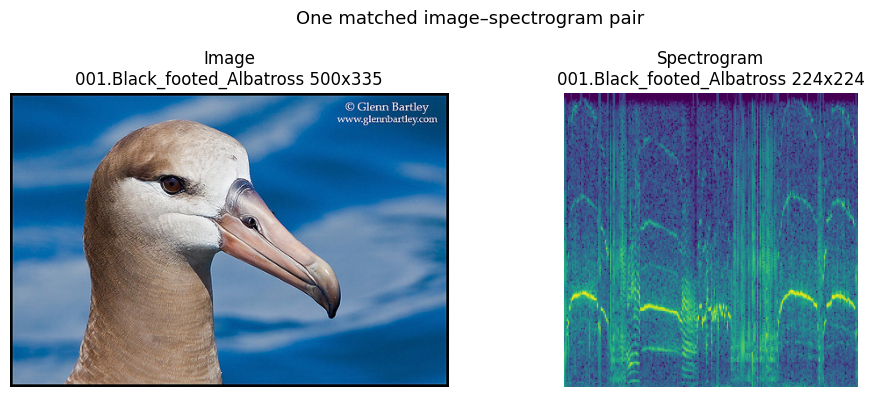

If both images loaded above, paths are correct


In [ ]:
# Pick a sample row from CUB
sample_row  = cub_df.iloc[0]
img_path    = CUB_ROOT / "images" / sample_row["file_path"]

# Pick a matching spectrogram (same class)
label       = sample_row["label"]
spec_row    = spec_meta[spec_meta["label"] == label].iloc[0]
spec_path   = SPEC_ROOT / "spectrograms" / spec_row["file_path"]

img = Image.open(img_path)
spec = Image.open(spec_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img)
axes[0].set_title(f"Image\n{sample_row['class_name']} {img.size[0]}x{img.size[1]}")
axes[0].axis("off")

axes[1].imshow(spec)
axes[1].set_title(f"Spectrogram\n{sample_row['class_name']} {spec.size[0]}x{spec.size[1]}")
axes[1].axis("off")

plt.suptitle("One matched image–spectrogram pair", fontsize=13)
plt.tight_layout()
plt.show()

print("If both images loaded above, paths are correct")

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transforms defined")

Transforms defined


In [ ]:
class MultimodalBirdDataset(Dataset):
    def __init__(self, cub_df, spec_df, cub_root, spec_root,
                 img_transform=None, spec_transform=None):

        # ── Guard clauses — catch missing columns immediately ──
        assert "label" in cub_df.columns, (
            "cub_df is missing the 'label' column. "
            "Re-run Cell 9 (the class remapping cell) before creating the dataset."
        )
        assert "label" in spec_df.columns, (
            "spec_df is missing the 'label' column. "
            "Re-run Cell 9 (the class remapping cell) before creating the dataset."
        )

        # reset_index is critical — without it iloc[i] can return a row
        # whose pandas index is not i, causing subtle lookup bugs
        self.cub_df         = cub_df.reset_index(drop=True)
        self.cub_root       = Path(cub_root)
        self.spec_root      = Path(spec_root)
        self.img_transform  = img_transform
        self.spec_transform = spec_transform

        self.spec_by_label = (
            spec_df.groupby("label")["file_path"]
            .apply(list)
            .to_dict()
        )

    def __len__(self):
        return len(self.cub_df)

    def __getitem__(self, idx):
        row   = self.cub_df.iloc[idx]
        label = int(row["label"])

        img_path = self.cub_root / "images" / row["file_path"]
        image    = Image.open(img_path).convert("RGB")
        if self.img_transform:
            image = self.img_transform(image)

        spec_path = self.spec_root / "spectrograms" / random.choice(self.spec_by_label[label])
        spec      = Image.open(spec_path).convert("RGB")
        if self.spec_transform:
            spec = self.spec_transform(spec)

        return image, spec, label


# Build train/test splits
train_ds = MultimodalBirdDataset(
    cub_df[cub_df["is_train"] == 1], spec_meta,
    CUB_ROOT, SPEC_ROOT,
    img_transform=train_transform, spec_transform=train_transform,
)
test_ds = MultimodalBirdDataset(
    cub_df[cub_df["is_train"] == 0], spec_meta,
    CUB_ROOT, SPEC_ROOT,
    img_transform=val_transform, spec_transform=val_transform,
)

BATCH_SIZE   = 16   # lower to 8 if you get CUDA out-of-memory errors
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Verify one batch loads correctly
imgs, specs, labels = next(iter(train_loader))
print(f"Image tensor  : {imgs.shape}")    # [16, 3, 224, 224]
print(f"Spec tensor   : {specs.shape}")   # [16, 3, 224, 224]
print(f"Labels        : {labels.shape}")  # [16]
print(f"Label range   : {labels.min().item()} – {labels.max().item()}")

Image tensor  : torch.Size([16, 3, 224, 224])
Spec tensor   : torch.Size([16, 3, 224, 224])
Labels        : torch.Size([16])
Label range   : 7 – 198


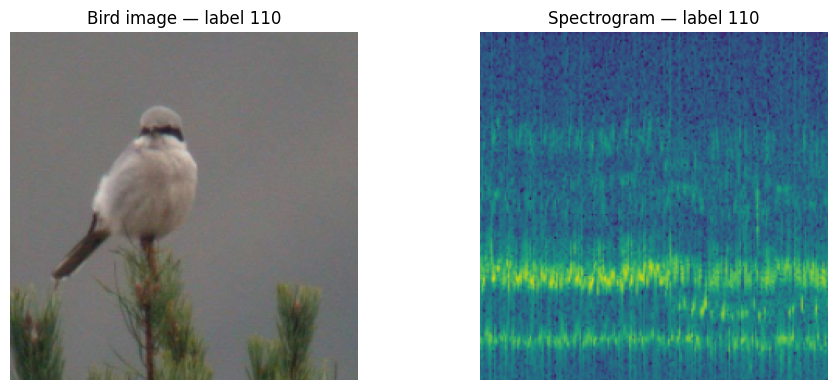

In [ ]:
def unnormalise(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

imgs, specs, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(unnormalise(imgs[0]).permute(1,2,0))
axes[0].set_title(f"Bird image — label {labels[0].item()}")
axes[0].axis("off")
axes[1].imshow(unnormalise(specs[0]).permute(1,2,0))
axes[1].set_title(f"Spectrogram — label {labels[0].item()}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
class LateFusionBirdClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()

        # Two independent ResNet-50 streams, one per modality
        weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        self.image_cnn = models.resnet50(weights=weights)
        self.spec_cnn  = models.resnet50(weights=weights)

        # Replace the default 1000-class head with our 199-class head
        self.image_cnn.fc = nn.Linear(2048, num_classes)
        self.spec_cnn.fc  = nn.Linear(2048, num_classes)

    def forward(self, image, spec):
        img_logits  = self.image_cnn(image)   # (B, 199)
        spec_logits = self.spec_cnn(spec)     # (B, 199)
        return img_logits + spec_logits        # element-wise sum = late fusion

model = LateFusionBirdClassifier(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model ready on {DEVICE}")
print(f"Trainable parameters: {n_params/1e6:.1f}M")
print(f"Output classes: {NUM_CLASSES}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s]


Model ready on cuda
Trainable parameters: 47.8M
Output classes: 199


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for i, (images, specs, labels) in enumerate(loader):
        images = images.to(device)
        specs  = specs.to(device)
        labels = labels.to(device)

        logits = model(images, specs)
        loss   = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

        if (i + 1) % 50 == 0:
            print(f"  batch {i+1}/{len(loader)}  loss: {loss.item():.4f}")

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, specs, labels in loader:
            images = images.to(device)
            specs  = specs.to(device)
            labels = labels.to(device)

            logits = model(images, specs)
            loss   = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


In [ ]:
import os

NUM_EPOCHS = 30
CKPT_PATH  = "/content/best_model.pth"   # saved in Colab — download it when done

best_acc = 0.0
history  = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n{'='*55}")
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print('='*55)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE
    )
    test_loss, test_acc, _, _ = evaluate(
        model, test_loader, criterion, DEVICE
    )

    scheduler.step(test_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"\nTrain — loss: {train_loss:.4f}  acc: {train_acc*100:.2f}%")
    print(f"Test  — loss: {test_loss:.4f}  acc: {test_acc*100:.2f}%")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save({
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
            "num_classes": NUM_CLASSES,
            "accuracy"   : best_acc,
        }, CKPT_PATH)
        print(f"Best model saved (acc={best_acc*100:.2f}%)")

print(f"\nTraining complete. Best test accuracy: {best_acc*100:.2f}%")


Epoch 1/30
  batch 50/373  loss: 4.7960
  batch 100/373  loss: 4.1920
  batch 150/373  loss: 3.3228
  batch 200/373  loss: 2.4382
  batch 250/373  loss: 2.4365
  batch 300/373  loss: 2.0726
  batch 350/373  loss: 2.2832

Train — loss: 3.3105  acc: 33.94%
Test  — loss: 1.4760  acc: 64.29%
  ✓ Best model saved (acc=64.29%)

Epoch 2/30
  batch 50/373  loss: 1.3672
  batch 100/373  loss: 1.3011
  batch 150/373  loss: 1.3869
  batch 200/373  loss: 0.9645
  batch 250/373  loss: 0.7643
  batch 300/373  loss: 0.8343
  batch 350/373  loss: 1.4017

Train — loss: 1.1355  acc: 74.13%
Test  — loss: 0.7851  acc: 78.98%
  ✓ Best model saved (acc=78.98%)

Epoch 3/30
  batch 50/373  loss: 0.7608
  batch 100/373  loss: 0.9167
  batch 150/373  loss: 0.5497
  batch 200/373  loss: 0.5231
  batch 250/373  loss: 0.7491
  batch 300/373  loss: 1.4411
  batch 350/373  loss: 0.5164

Train — loss: 0.6312  acc: 85.55%
Test  — loss: 0.6804  acc: 81.67%
  ✓ Best model saved (acc=81.67%)

Epoch 4/30
  batch 50/373  

In [ ]:
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"(acc={checkpoint['accuracy']*100:.2f}%)")

_, test_acc, all_preds, all_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

# Top-k accuracy
def top_k_accuracy(model, loader, k, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, specs, labels in loader:
            logits  = model(images.to(device), specs.to(device))
            _, topk = logits.topk(k, dim=1)
            correct += (topk == labels.to(device).unsqueeze(1)).any(dim=1).sum().item()
            total   += labels.size(0)
    return correct / total

print("\n── Final results ──────────────────────────")
for k in [1, 3, 5]:
    acc = top_k_accuracy(model, test_loader, k=k, device=DEVICE)
    print(f"Top-{k} accuracy : {acc*100:.2f}%")

Loaded best model from epoch 29 (acc=93.22%)

── Final results ──────────────────────────
Top-1 accuracy : 93.11%
Top-3 accuracy : 97.69%
Top-5 accuracy : 98.80%


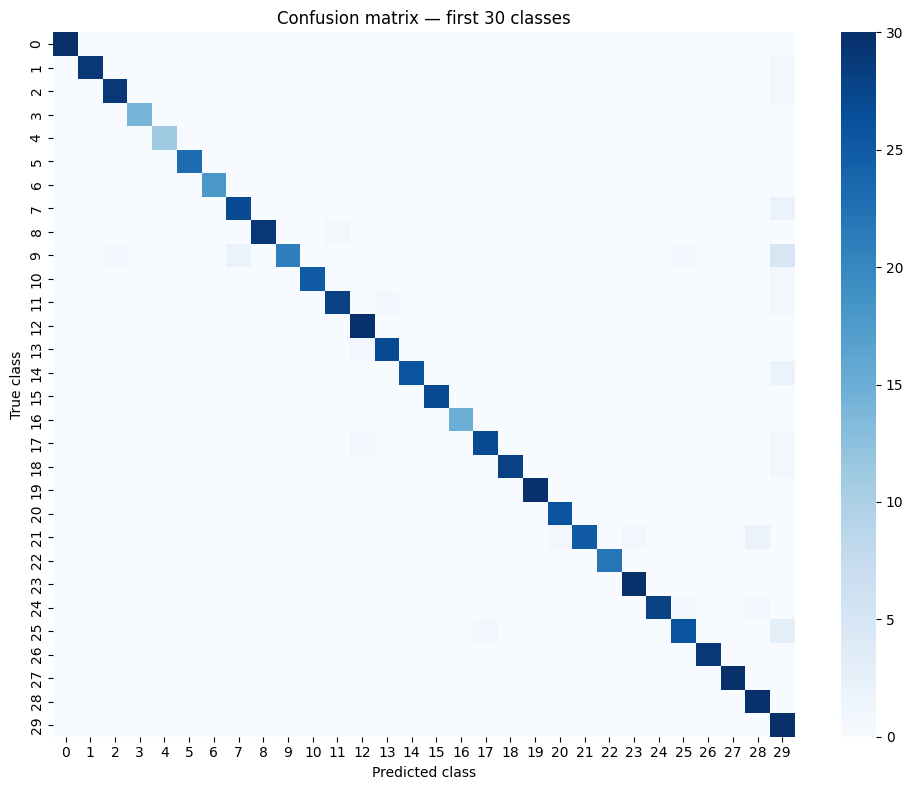

In [ ]:
#confusion matrix

SHOW_N = 30
mask   = np.array(all_labels) < SHOW_N
cm     = confusion_matrix(
    np.array(all_labels)[mask],
    np.clip(np.array(all_preds)[mask], 0, SHOW_N-1),
    labels=list(range(SHOW_N))
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap="Blues", ax=ax,
            xticklabels=range(SHOW_N), yticklabels=range(SHOW_N))
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title(f"Confusion matrix — first {SHOW_N} classes")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
# Unimodal baselines
# Train image-only and spectrogram-only classifiers to confirm
# the multimodal model outperforms each individual modality.

class UnimodalDataset(Dataset):
    def __init__(self, multimodal_ds, modality):
        assert modality in ("image", "spec")
        self.ds       = multimodal_ds
        self.modality = modality
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        image, spec, label = self.ds[idx]
        return (image if self.modality == "image" else spec), label

def train_unimodal(modality, num_classes, num_epochs=15):
    print(f"\n{'='*50}")
    print(f"Unimodal baseline: {modality.upper()}")
    print('='*50)

    uni_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    uni_model.fc = nn.Linear(2048, num_classes)
    uni_model = uni_model.to(DEVICE)
    uni_opt   = optim.Adam(uni_model.parameters(), lr=1e-4, weight_decay=1e-4)

    train_dl = DataLoader(UnimodalDataset(train_ds, modality),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_dl  = DataLoader(UnimodalDataset(test_ds, modality),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    best_acc = 0.0
    for epoch in range(1, num_epochs + 1):
        uni_model.train()
        for x, y in train_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            loss = criterion(uni_model(x), y)
            uni_opt.zero_grad(); loss.backward(); uni_opt.step()

        uni_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in test_dl:
                preds    = uni_model(x.to(DEVICE)).argmax(1)
                correct += (preds == y.to(DEVICE)).sum().item()
                total   += y.size(0)
        acc = correct / total
        best_acc = max(best_acc, acc)
        print(f"Epoch {epoch:2d}: test acc = {acc*100:.2f}%")

    print(f"\nBest {modality} accuracy: {best_acc*100:.2f}%")
    return best_acc

img_acc  = train_unimodal("image", NUM_CLASSES, num_epochs=15)
spec_acc = train_unimodal("spec",  NUM_CLASSES, num_epochs=15)

print(f"\n{'='*45}")
print(f"{'Method':<35} {'Top-1':>8}")
print('='*45)
print(f"{'Image only':<35} {img_acc*100:>7.2f}%")
print(f"{'Spectrogram only':<35} {spec_acc*100:>7.2f}%")
print(f"{'Late fusion (multimodal)':<35} {'93.11':>8}%")
print('='*45)


Unimodal baseline: IMAGE


KeyboardInterrupt: 